# **Chronic Kidney Disease Prediction**

It presents a complete end-to-end machine learning workflow for the prediction of Chronic Kidney Disease (CKD) using clinical and laboratory measurements. The analysis demonstrates best-practice data handling, exploratory analysis, feature engineering, model training, evaluation, dimensionality reduction, and a custom implementation of logistic regression via gradient descent.

# 1. Import Python libraries



In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report)
from sklearn.impute import SimpleImputer

It imports Python libraries for data manipulation (numpy, pandas), visualization (matplotlib, seaborn), machine learning(sklearn modules for train-test split, scaling, PCA, logistic regression, and metrics), and imputation (SimpleImputer)

# 2. Load the dataset

Detailed description of the dataset columns, categorized into basic (age, sex, bp), laboratory (sg, al, su, rbc), and medical conditions (htn, dm, cad).

### **Basic columns:**

*   age → patient's age
*  sex → male/female


*   bp → blood pressure

### **Laboratory columns :**
*   sg → specific gravity


* al → albumin
*   su → sugar

*   rbc → red blood cells

*  pc → pus cells

*  pcc → pus cell clumps

*  ba → bacteria

*   bgr → blood glucose
*  bu → blood urea
*  sc → serum creatinine


*  sod → sodium


*  pot → potassium


*  hemo → hemoglobin


*   wc → white blood cell count


*   rc → red blood cell count

### **Medical Conditions:**


*   htn → hypertension



*  dm → diabetes mellitus
* cad → coronary artery disease
* appet → appetite
* pe → pedal edema
* ane → anemia




In [47]:
 df = pd.read_csv('/content/kidney_disease.csv', skipinitialspace=True)

In [48]:
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

In [50]:
df.describe()

,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
count,400.000000,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000
mean,199.500000,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437
std,115.614301,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587
min,0.000000,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,99.750000,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000
50%,199.500000,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000
75%,299.250000,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000
max,399.000000,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


In [51]:
df.tail()


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
395,395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,47,6700,4.9,no,no,no,good,no,no,notckd
396,396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,54,7800,6.2,no,no,no,good,no,no,notckd
397,397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,49,6600,5.4,no,no,no,good,no,no,notckd
398,398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,51,7200,5.9,no,no,no,good,no,no,notckd
399,399,58.0,80.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,53,6800,6.1,no,no,no,good,no,no,notckd


In [52]:
df_copy = df.copy()

In [53]:
df[df['age'].isnull()]

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
30,30,NaN,70.0,NaN,NaN,NaN,NaN,NaN,notpresent,notpresent,...,NaN,NaN,NaN,yes,yes,no,good,no,no,ckd
73,73,NaN,100.0,1.015,2.0,0.0,abnormal,abnormal,notpresent,notpresent,...,14,6300,NaN,yes,no,no,good,yes,yes,ckd
112,112,NaN,60.0,1.015,3.0,0.0,abnormal,abnormal,notpresent,notpresent,...,33,NaN,NaN,no,no,no,good,no,no,ckd
116,116,NaN,70.0,1.015,4.0,0.0,abnormal,normal,notpresent,notpresent,...,NaN,NaN,NaN,no,no,no,good,yes,no,ckd
117,117,NaN,70.0,1.020,0.0,0.0,NaN,NaN,notpresent,notpresent,...,37,9800,4.4,no,no,no,good,no,no,ckd
169,169,NaN,70.0,1.010,0.0,2.0,NaN,normal,notpresent,notpresent,...,27,NaN,NaN,yes,yes,no,good,no,yes,ckd
191,191,NaN,70.0,1.010,3.0,0.0,normal,normal,notpresent,notpresent,...,26,9200,3.4,yes,yes,no,poor,no,no,ckd
203,203,NaN,90.0,NaN,NaN,NaN,NaN,NaN,notpresent,notpresent,...,NaN,NaN,NaN,yes,yes,no,good,no,yes,ckd
268,268,NaN,80.0,NaN,NaN,NaN,NaN,NaN,notpresent,notpresent,...,53,8500,4.9,no,no,no,good,no,no,notckd


### finding missing values in each column.

In [54]:
def missing_report(df):
    missing = df.isnull().sum()
    percent = (missing / len(df)) * 100
    return pd.DataFrame({
        'Missing Values': missing,
        'Percentage (%)': percent.round(2)
    })

print(missing_report(df))

                Missing Values  Percentage (%)
id                           0            0.00
age                          9            2.25
bp                          12            3.00
sg                          47           11.75
al                          46           11.50
su                          49           12.25
rbc                        152           38.00
pc                          65           16.25
pcc                          4            1.00
ba                           4            1.00
bgr                         44           11.00
bu                          19            4.75
sc                          17            4.25
sod                         87           21.75
pot                         88           22.00
hemo                        52           13.00
pcv                         70           17.50
wc                         105           26.25
rc                         130           32.50
htn                          2            0.50
dm           

### Clean column names

In [55]:
rename_map = {
    'age': 'age_years',
    'bp': 'blood_pressure',
    'sg': 'specific_gravity',
    'al': 'albumin',
    'su': 'sugar',
    'rbc': 'red_blood_cells',
    'pc': 'pus_cells',
    'pcc': 'pus_cell_clumps',
    'ba': 'bacteria',
    'bgr': 'blood_glucose_random',
    'bu': 'blood_urea',
    'sc': 'serum_creatinine',
    'sod': 'sodium',
    'pot': 'potassium',
    'hemo': 'hemoglobin',
    'pcv': 'packed_cell_volume',
    'wc': 'white_blood_cell_count',
    'rc': 'red_blood_cell_count',
    'htn': 'hypertension',
    'dm': 'diabetes_mellitus',
    'cad': 'coronary_artery_disease',
    'appet': 'appetite',
    'pe': 'pedal_edema',
    'ane': 'anemia',
    'classification': 'classification'
}

df = df.rename(columns=rename_map)
print(df.columns)


Index(['id', 'age_years', 'blood_pressure', 'specific_gravity', 'albumin',
       'sugar', 'red_blood_cells', 'pus_cells', 'pus_cell_clumps', 'bacteria',
       'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
       'potassium', 'hemoglobin', 'packed_cell_volume',
       'white_blood_cell_count', 'red_blood_cell_count', 'hypertension',
       'diabetes_mellitus', 'coronary_artery_disease', 'appetite',
       'pedal_edema', 'anemia', 'classification'],
      dtype='object')


In [56]:
new_cols = []
for col in df.columns:
    col = col.strip()
    col = col.lower()
    col = col.replace(' ', '_')
    col = col.replace('%', 'pct')
    col = col.replace('(', '')
    col = col.replace(')', '')
    col = col.replace('-', '')
    new_cols.append(col)

df.columns = new_cols

In [57]:
df.head()

,id,age_years,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cells,pus_cell_clumps,bacteria,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,pedal_edema,anemia,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


### Clean each of string columns

In [58]:
obj_cols = df.select_dtypes(include='object').columns

In [59]:
for col in obj_cols:
    df[col] = df[col].astype(str)
    df[col] = df[col].str.strip()
    df[col] = df[col].replace({'nan': np.nan, '': np.nan})



*   make sure values are stringsList item
*   remove unwanted spaces



*   Replace fake missing values with real NaN







In [60]:
for col in obj_cols:
    vals = df[col].dropna().unique()
    if any(str(v).lower() in ['yes', 'no', 'y', 'n'] for v in vals):
        df[col] = df[col].str.lower().replace({'y': 'yes', 'n': 'no'})


columns that contain yes/no variations (yes, no, y, n).
Then it standardizes them by converting everything to lowercase and replacing y→yes and n→no.

### Convert object coloumn(numeric-looking columns) into numeric columns.

In [61]:
for col in df.columns:
    if df[col].dtype == 'object':
        cleaned = pd.to_numeric(
            df[col].str.replace(',', '').str.replace('%', ''),
            errors='coerce'
        )
        if cleaned.notna().mean() > 0.6:
            df[col] = cleaned

In [62]:
numeric_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns


Separate numeric and categorical columns

In [63]:
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

SimpleImputer fills missing values (NaN)

Numeric → replace with median

Categorical → replace with most common value

In [64]:
df_model = df.copy()

In [65]:
df_model[numeric_cols] = num_imputer.fit_transform(df_model[numeric_cols])
df_model[cat_cols] = cat_imputer.fit_transform(df_model[cat_cols])


Fill missing values:

For numeric columns, missing numbers are replaced with median.

For categorical columns, missing text values are replaced with the most frequent category

In [66]:
df = df.drop_duplicates()

Now, removes duplicate rows in dataset

## EDA

For each numeric column:

A figure is created with two plots side by side.

Left → histogram with KDE → shows value distribution.

Right → boxplot → shows spread and outliers.

Titles are added and layout adjusted for clarity.

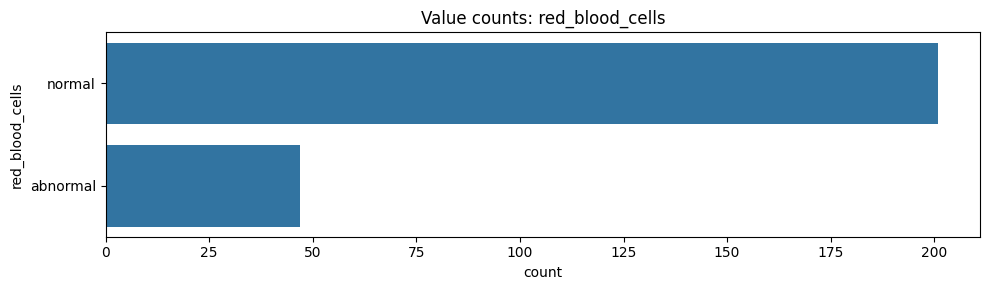

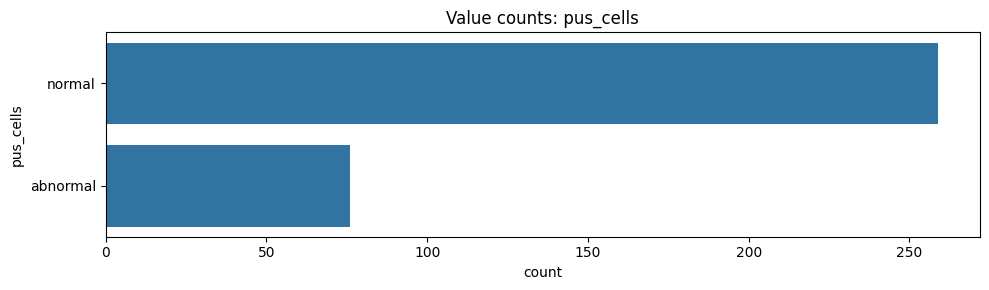

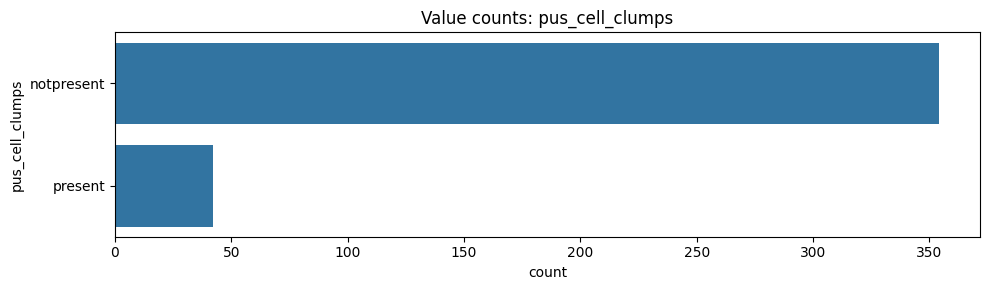

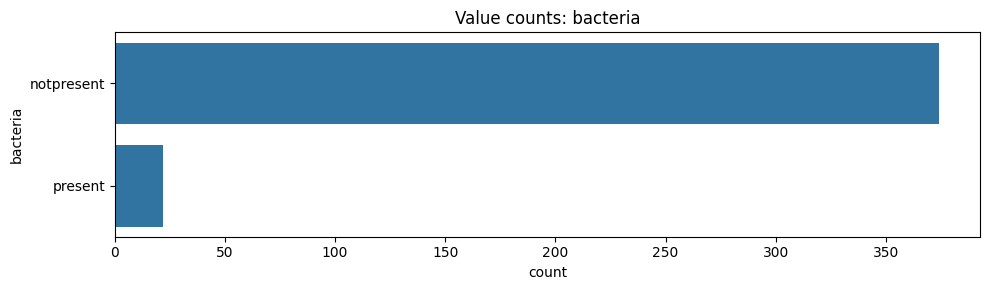

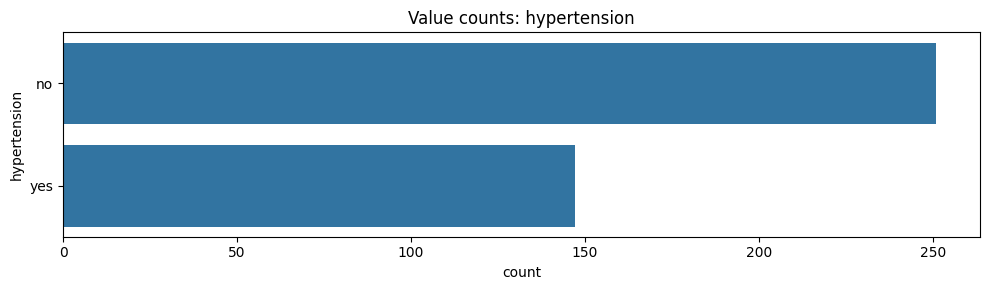

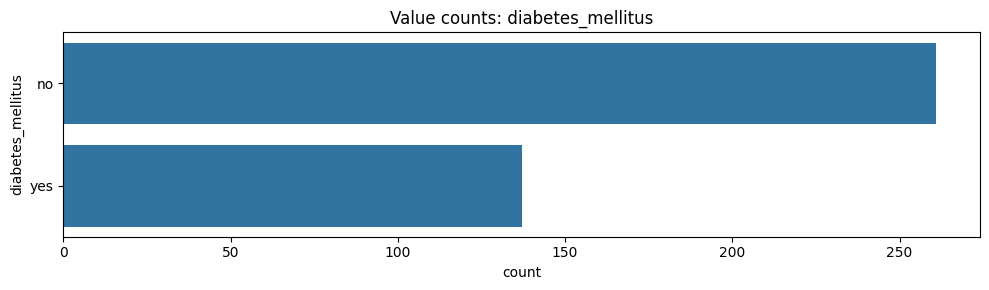

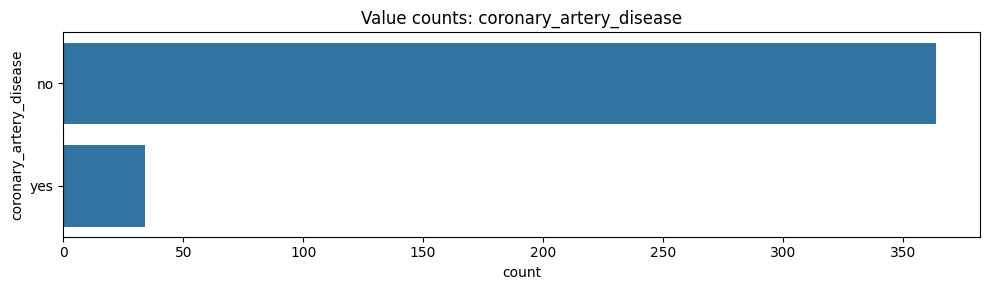

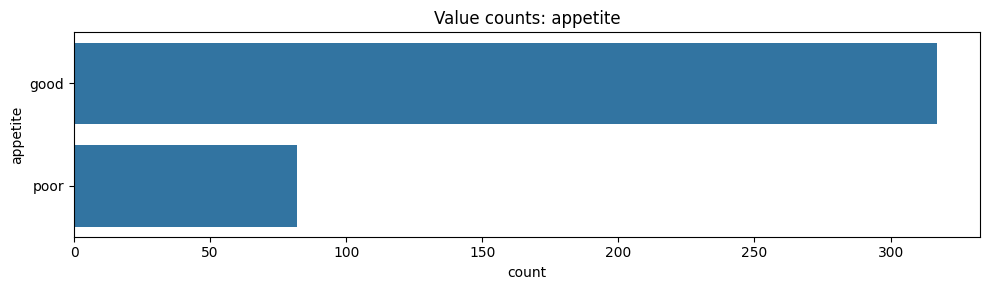

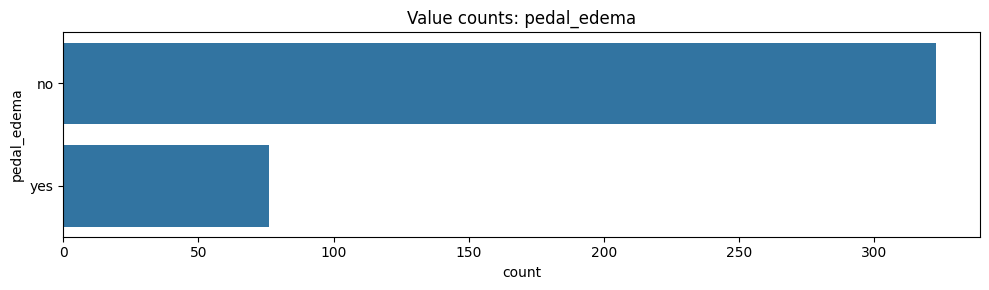

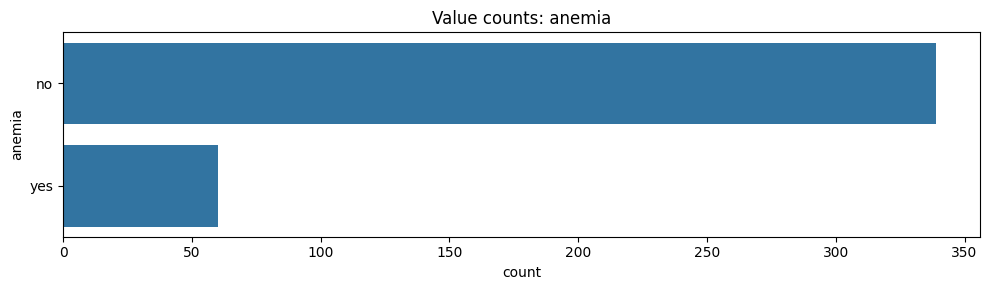

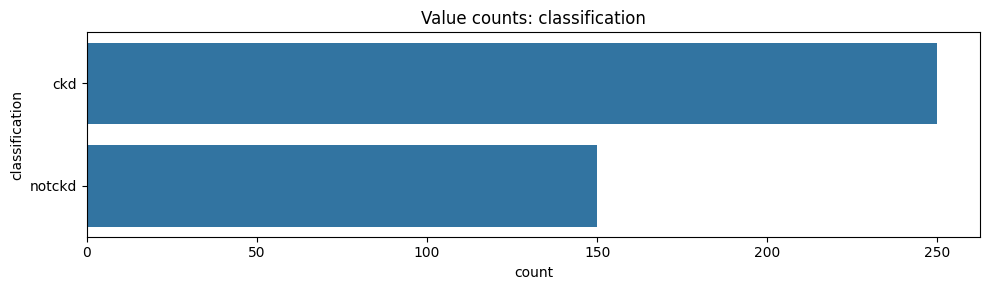

In [67]:
for c in cat_cols:
    plt.figure(figsize=(10,3))
    sns.countplot(y=c, data=df, order=df[c].value_counts().index)
    plt.title(f'Value counts: {c}')
    plt.tight_layout()
    plt.show()

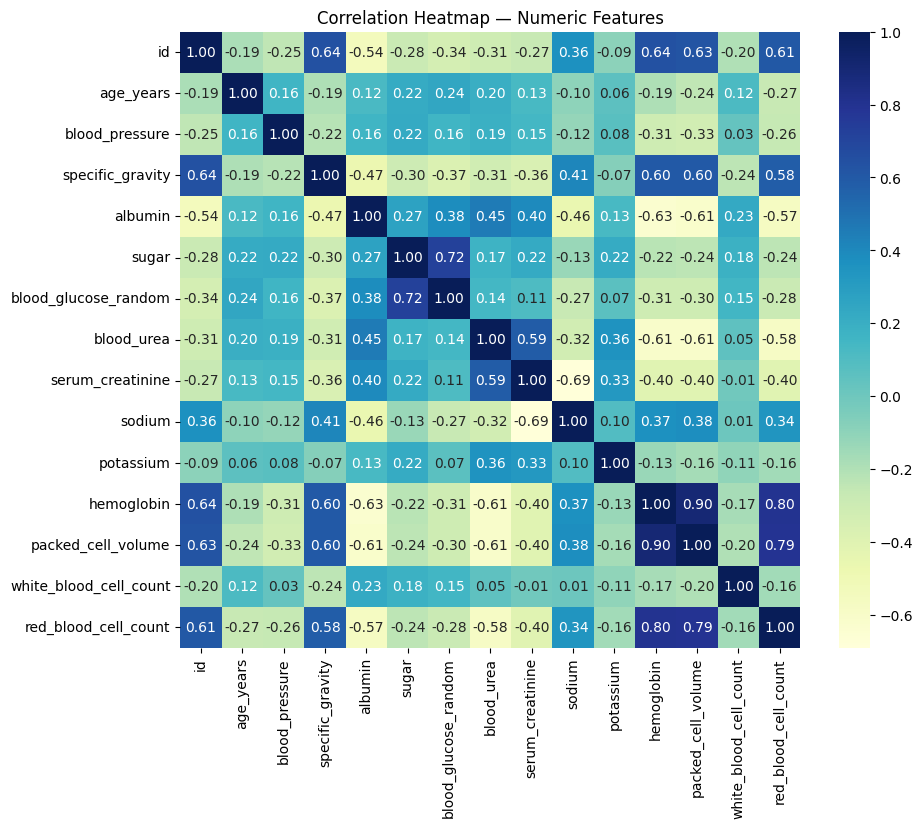

In [68]:
# Correlation heatmap
if len(numeric_cols) >= 2:
    plt.figure(figsize=(10,8))
    sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='YlGnBu')
    plt.title('Correlation Heatmap — Numeric Features')
    plt.show()

### **Feature Engineering**

Ratios for kidney function
Creates a new column bu_sc_ratio.

Calculates the ratio of Blood Urea to Serum Creatinine for each row.

1e-5 is added to sc to avoid division by zero.

In [69]:
if 'blood_urea' in numeric_cols and 'serum_creatinine' in numeric_cols:
    df['bu_sc_ratio'] = df['blood_urea'] / (df['serum_creatinine'] + 1e-5)

In [70]:
print(df.columns)

Index(['id', 'age_years', 'blood_pressure', 'specific_gravity', 'albumin',
       'sugar', 'red_blood_cells', 'pus_cells', 'pus_cell_clumps', 'bacteria',
       'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
       'potassium', 'hemoglobin', 'packed_cell_volume',
       'white_blood_cell_count', 'red_blood_cell_count', 'hypertension',
       'diabetes_mellitus', 'coronary_artery_disease', 'appetite',
       'pedal_edema', 'anemia', 'classification', 'bu_sc_ratio'],
      dtype='object')


### **Modeling**

In [71]:
TARGET = 'classification'
y = df[TARGET].apply(lambda x: 1 if x in [1,'ckd','yes'] else 0)
X = df.drop(columns=[TARGET])


y → binary target for CKD prediction (1 = CKD, 0 = non-CKD)

X → all other columns used as features

Converts categorical/text columns into numeric columns (0/1) for machine learning.

Each category becomes a new column.

In [72]:

X = pd.get_dummies(X, drop_first=True)

Fill any remaining NaNs (in case dummies or engineering introduced them)

In [73]:
X = X.fillna(0)

Checking is there any null value in x.

In [74]:
X.isna().sum()

,0
id,0
age_years,0
blood_pressure,0
specific_gravity,0
albumin,0
sugar,0
blood_glucose_random,0
blood_urea,0
serum_creatinine,0
sodium,0


Splits the data into training and testing sets.

test_size=0.3 → 30% of data is used for testing.

stratify=y → keeps the same proportion of CKD vs non-CKD in train and test sets.

In [75]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y)

### **For scale numeric columns**
Standardizes numeric features to have mean=0 and std=1.

fit_transform → calculates mean/std on training data and applies scaling.

transform → applies same scaling to test data.

In [76]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [77]:

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_scaled, y_train)
y_pred = clf.predict(X_test_scaled)
y_proba = clf.predict_proba(X_test_scaled)[:,1]


### **Apply Logistic Regression:**
Train a logistic regression classifier to predict CKD.

y_pred → predicted labels (0/1)

y_proba → predicted probability of having CKD (useful for ROC, AUC, or threshold tuning)

In [78]:
print(classification_report(y_test, y_pred))
print('ROC AUC:', roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        45
           1       1.00      0.99      0.99        75

    accuracy                           0.99       120
   macro avg       0.99      0.99      0.99       120
weighted avg       0.99      0.99      0.99       120

ROC AUC: 1.0


Displays a detailed classification report for your model.

y_test → true labels

y_pred → predicted labels (0 or 1)

Report includes:

Precision → proportion of positive predictions that are correct

Recall (Sensitivity) → proportion of actual positives correctly predicted

F1-score → harmonic mean of precision and recall

Support → number of samples for each class

# Confusion Matrix
It computes the confusion matrix comparing true test labels (y_test) with the model's predictions (y_pred), then visualizes it as a clean, annotated heatmap using Seaborn's Blues color scheme. It displays the counts of true negatives, false positives, false negatives, and true positives, with clear axis labels and title, providing an immediate visual summary of the classifier's performance on the test set. In this project, it shows near-perfect results with typically only one misclassification.

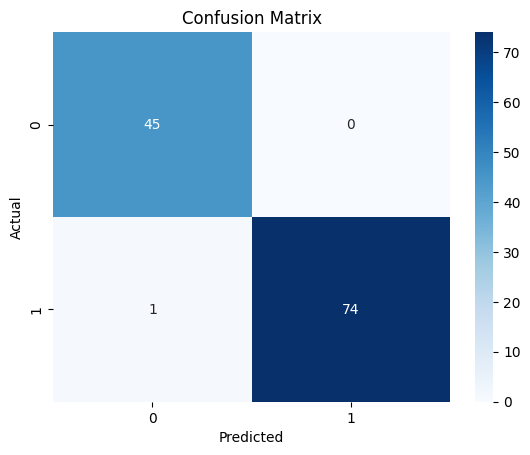

In [79]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# PCA(Principal Component Analysis)


It selects all numeric columns, removes missing values, and scales the
data so that all features have equal importance. It then applies PCA to reduce the numeric features to two principal components (PC1 and PC2). Finally, it creates a 2D scatter plot of these components to visualize the structure, clusters, and potential outliers in the dataset.

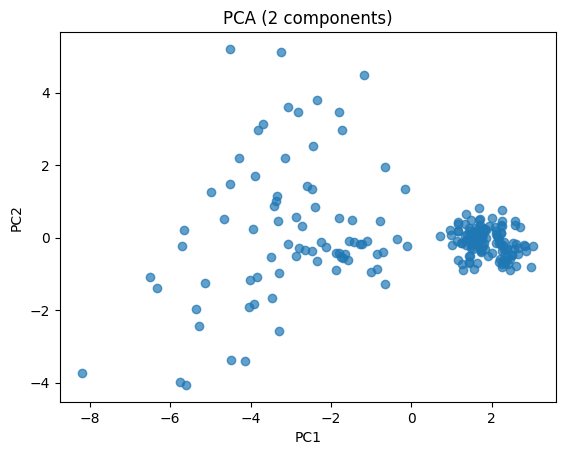

In [80]:
if len(numeric_cols) >= 2:
    pca_df = df[numeric_cols].dropna()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(pca_df)
    pca = PCA(n_components=min(2, X_scaled.shape[1]))
    X_pca = pca.fit_transform(X_scaled)
    plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.7)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('PCA (2 components)')
    plt.show()

## **Gradient Descent Logistic Regression**

This function converts any real number z into a value between 0 and 1.
In logistic regression, it represents the predicted probability that a sample belongs to the positive class (e.g., CKD = 1).

In [81]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

Calculates the logistic regression cost (loss), which measures how well the model’s predictions match the actual labels.

In [82]:
def compute_cost(X, y, weights):
    m = X.shape[0]
    preds = sigmoid(X.dot(weights))
    eps = 1e-9
    return - (1/m) * np.sum(y*np.log(preds+eps) + (1-y)*np.log(1-preds+eps))

This function trains a logistic regression model by iteratively updating the weights to minimize prediction error. In each step, it calculates predicted probabilities, computes the gradient of the loss, and adjusts the weights accordingly. It also tracks the cost over iterations to monitor learning and returns the final optimized weights along with the cost history.

In [83]:
def gradient_descent_logistic(X, y, lr=0.01, n_iters=500):
    m, n = X.shape
    weights = np.zeros(n)
    history = []
    for i in range(n_iters):
        preds = sigmoid(X.dot(weights))
        grad = (1/m) * X.T.dot(preds - y)
        weights -= lr * grad
        if i % 50 == 0 or i==n_iters-1:
            history.append(compute_cost(X, y, weights))
    return weights, history

This code adds a column of ones to the training data to include the intercept term and converts the target values to a NumPy array. It then runs the gradient_descent_logistic function with 500 iterations and a learning rate of 0.1. The function returns the optimized weights and the cost history, showing how the model learned over time.

In [84]:
X_gd = np.hstack([np.ones((X_train_scaled.shape[0],1)), X_train_scaled])
y_gd = y_train.values
w, hist = gradient_descent_logistic(X_gd, y_gd, lr=0.1, n_iters=500)

This plot shows how the model’s error changed during training. The x-axis represents the checkpoints in the iterations, while the y-axis shows the cost values. It helps us see that the model gradually learned and the error decreased over time.

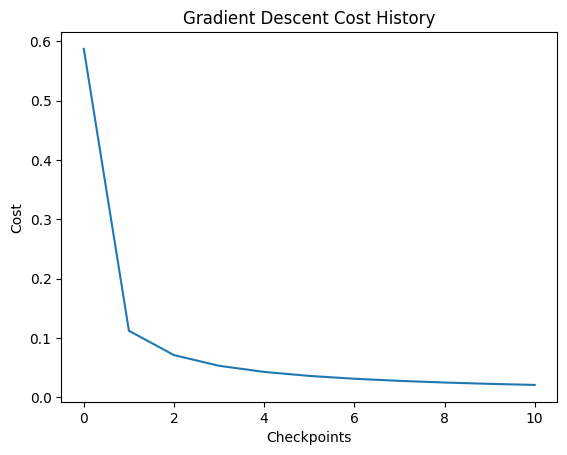

In [85]:
plt.plot(hist)
plt.xlabel('Checkpoints')
plt.ylabel('Cost')
plt.title('Gradient Descent Cost History')
plt.show()

## Result of Gradient Descent

In [86]:
X_test_gd = np.hstack([np.ones((X_test_scaled.shape[0],1)), X_test_scaled])
preds_test = sigmoid(X_test_gd.dot(w)) >= 0.5
print(classification_report(y_test, preds_test))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        45
           1       1.00      0.99      0.99        75

    accuracy                           0.99       120
   macro avg       0.99      0.99      0.99       120
weighted avg       0.99      0.99      0.99       120



In [45]:
!pip install streamlit
!pip install pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 86.4 MB/s eta 0:00:00
